In [ ]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

import pymc as pm
import pytensor.tensor as pt
import pytensor
from tqdm.notebook import tqdm
pytensor.config.cxx = '/usr/bin/clang++'

from modulars import plot_a_few_trajectories_1d, plot_mean_band_rrs_1d
from modulars import load_config, load_best_values
from modulars import pushforward_exp_mean_std, traces_to_lambda_moments
from modulars import exponential, print_model_info
from modulars import run_pymc_VI, run_single_seed_pymc_VI
trace_fn = pushforward_exp_mean_std
pushforward_fn = traces_to_lambda_moments
# trace_fn is applied to the best values (scalars)
# pushforward_fn is applied to the trajectories (arrays)

In [4]:
config_file = '../exp_config.json'
config = load_config(config_file)

lambda_like = config['lambda_like']
alpha_prior = config['alpha_prior']
beta_prior = config['beta_prior']
n_samples = config['n_samples']
grad_samps = config['grad_samps']
max_iters = 100_000#config['max_iters']
data = exponential(n_samples)
print_model_info(
    "Gamma", "Exp", "Gamma",
    [alpha_prior, beta_prior], [lambda_like],
    data=data, n_samples=n_samples
)


Prior: Gamma([1.5, 1.0])
Likelihood: Exp([2.0])
Data: []


In [ ]:

def run_model(n_mc_samples = 1, optimizer = 'default', seed = 0):
    with pm.Model() as model:
        lambd = pm.Gamma('lambda', alpha=alpha_prior, beta=beta_prior)

        # Likelihood
        likelihood = pm.Exponential('likelihood', lam=1/lambd, observed=data)

        # run my pymc wrapper that allows for random restarts 
        # and tracking values across MC samples and optimizers
        tracked_vals = run_pymc_VI(model, n_mc_samples, max_iters, optimizer, seed)
    return tracked_vals


In [ ]:
results = []
results_adam = []
for seed in tqdm(range(50)):
    all_results = run_single_seed_pymc_VI(seed, run_model)
    results.append(all_results[0])
    results_adam.append(all_results[1])

  0%|          | 0/50 [00:00<?, ?it/s]

Finished [100%]: Average Loss = 0.11851
Finished [100%]: Average Loss = 0.053758
Finished [100%]: Average Loss = 0.065017
Finished [100%]: Average Loss = 0.053792
Finished [100%]: Average Loss = 0.11555
Finished [100%]: Average Loss = 0.054166
Finished [100%]: Average Loss = 0.04929
Finished [100%]: Average Loss = 0.054201
Finished [100%]: Average Loss = 0.1015
Finished [100%]: Average Loss = 0.054728
Finished [100%]: Average Loss = 0.048048
Finished [100%]: Average Loss = 0.054765
Finished [100%]: Average Loss = 0.13225
Finished [100%]: Average Loss = 0.053643
Finished [100%]: Average Loss = 0.060633
Finished [100%]: Average Loss = 0.053668
Finished [100%]: Average Loss = 0.11534
Finished [100%]: Average Loss = 0.055198
Finished [100%]: Average Loss = 0.070261
Finished [100%]: Average Loss = 0.055273
Finished [100%]: Average Loss = 0.1183
Finished [100%]: Average Loss = 0.057471
Finished [100%]: Average Loss = 0.061597
Finished [100%]: Average Loss = 0.057532
Finished [100%]: Average 

In [ ]:
from modulars import apply_traj_transform
single_means, single_stds, multi_means, multi_stds = \
    apply_traj_transform(results, pushforward_fn, n_samples=10_000, seed=1, NOTEBOOK=True)

single_means_adam, single_stds_adam, multi_means_adam, multi_stds_adam = \
    apply_traj_transform(results_adam, pushforward_fn, n_samples=10_000, seed=1, NOTEBOOK=True)

N, T = single_means.shape
x = np.arange(T)

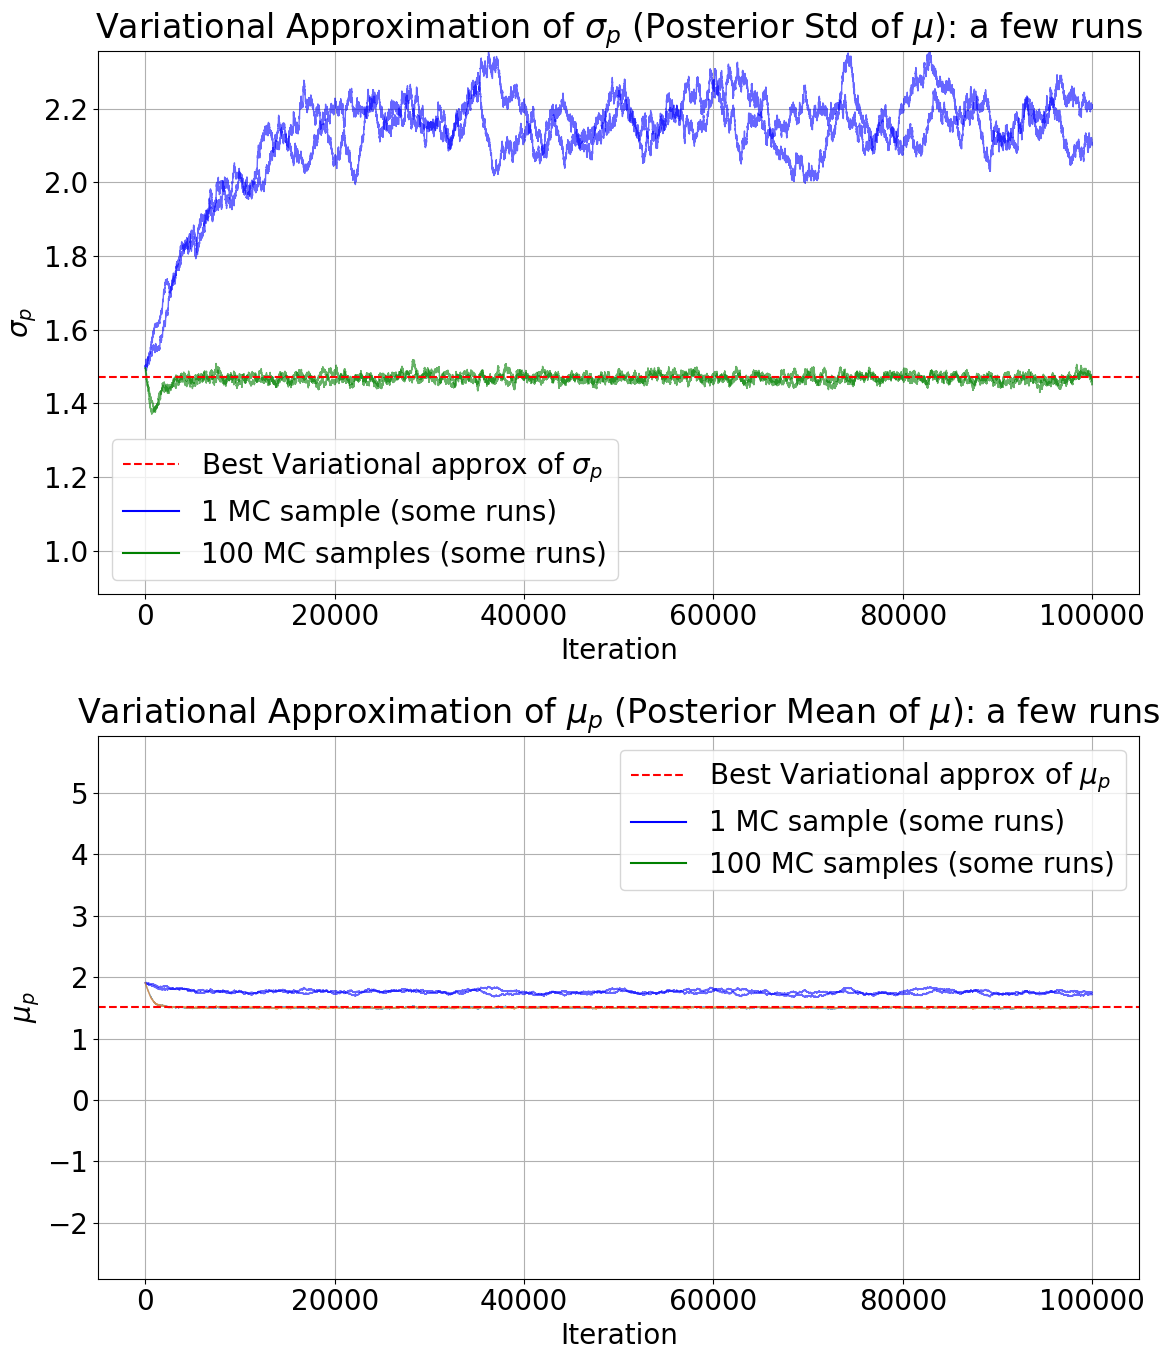

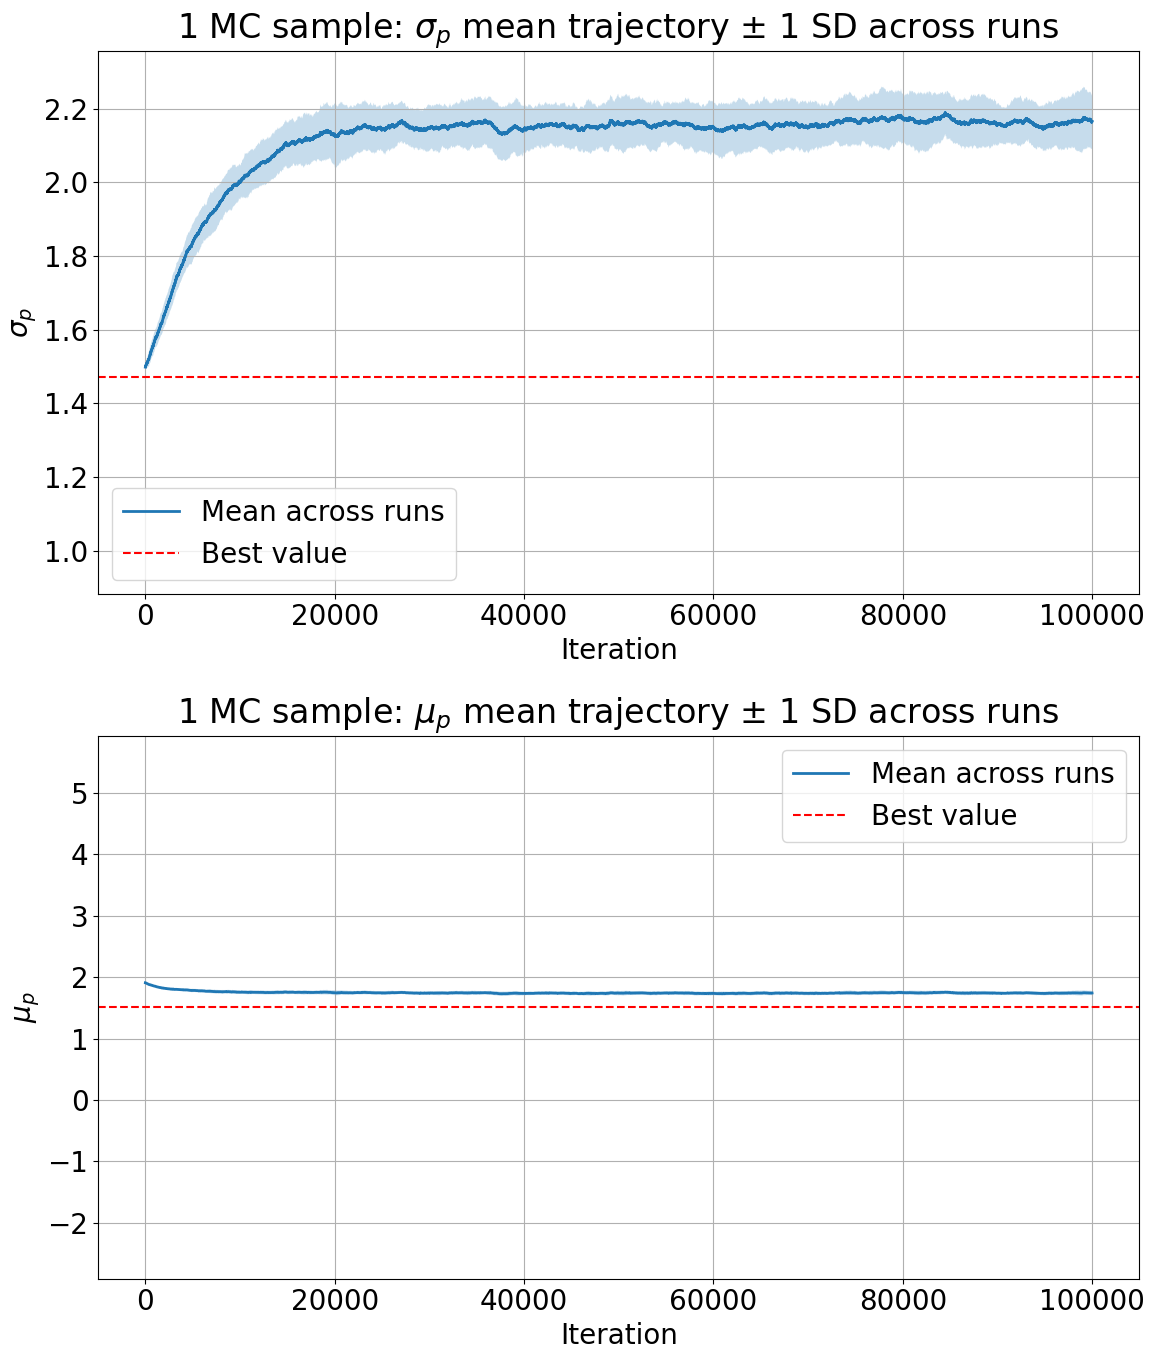

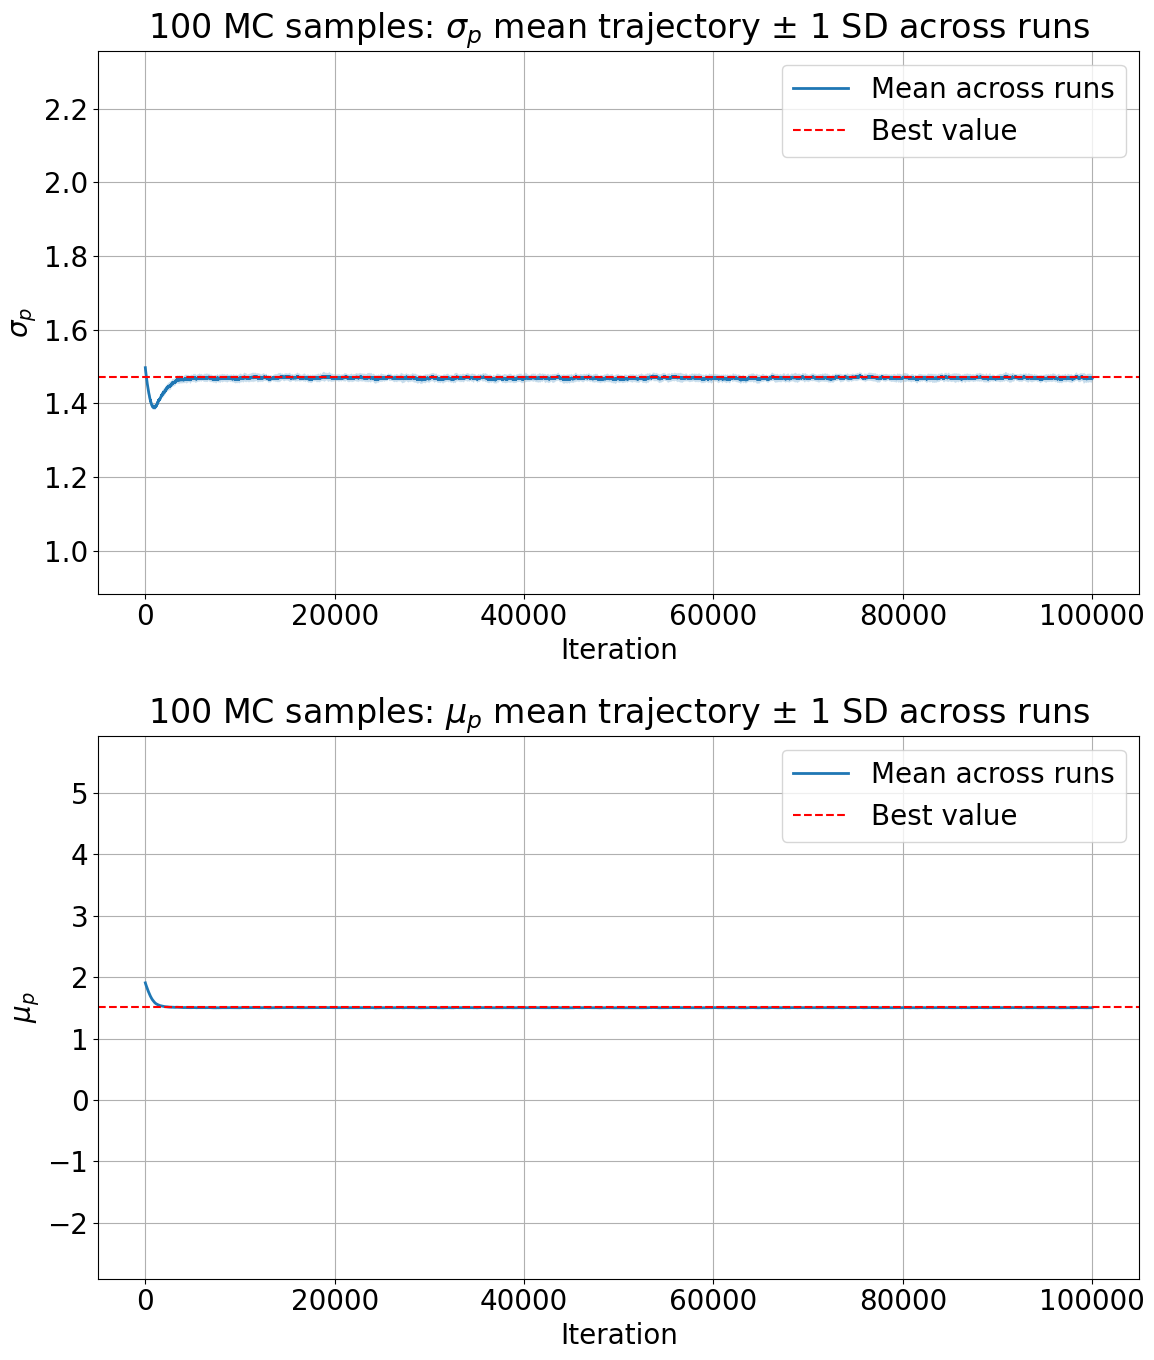

In [ ]:
# If we have "best" from config, these should be on theta-scale (0,1)
best_mu, best_std = load_best_values(
    config=config, transform=trace_fn,
    n_samples=50_000, seed=1)


plot_a_few_trajectories_1d(
    [single_means, single_stds], [multi_means, multi_stds],
    best_mu, best_std, r'$\lambda$')
plot_mean_band_rrs_1d(
    single_means, single_stds, best_mu, best_std,
    x, r'$\lambda$', 1)
plot_mean_band_rrs_1d(
    multi_means, multi_stds, best_mu, best_std,
    x, r'$\lambda$', 100)

# Adam results

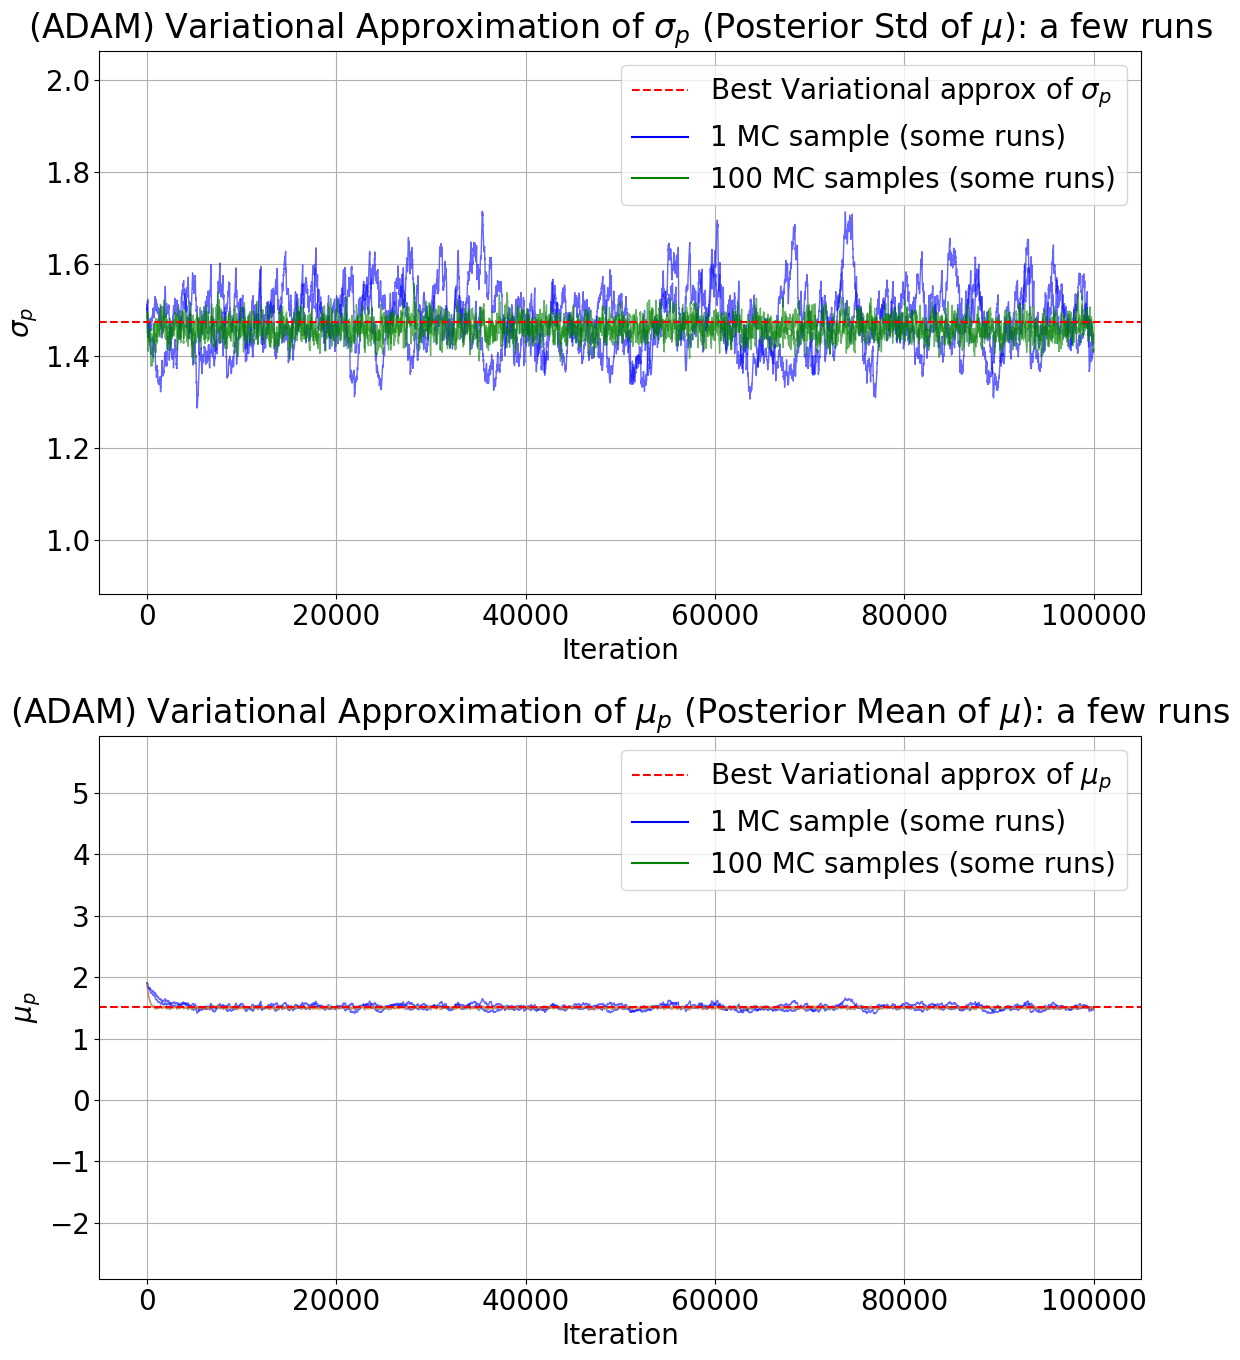

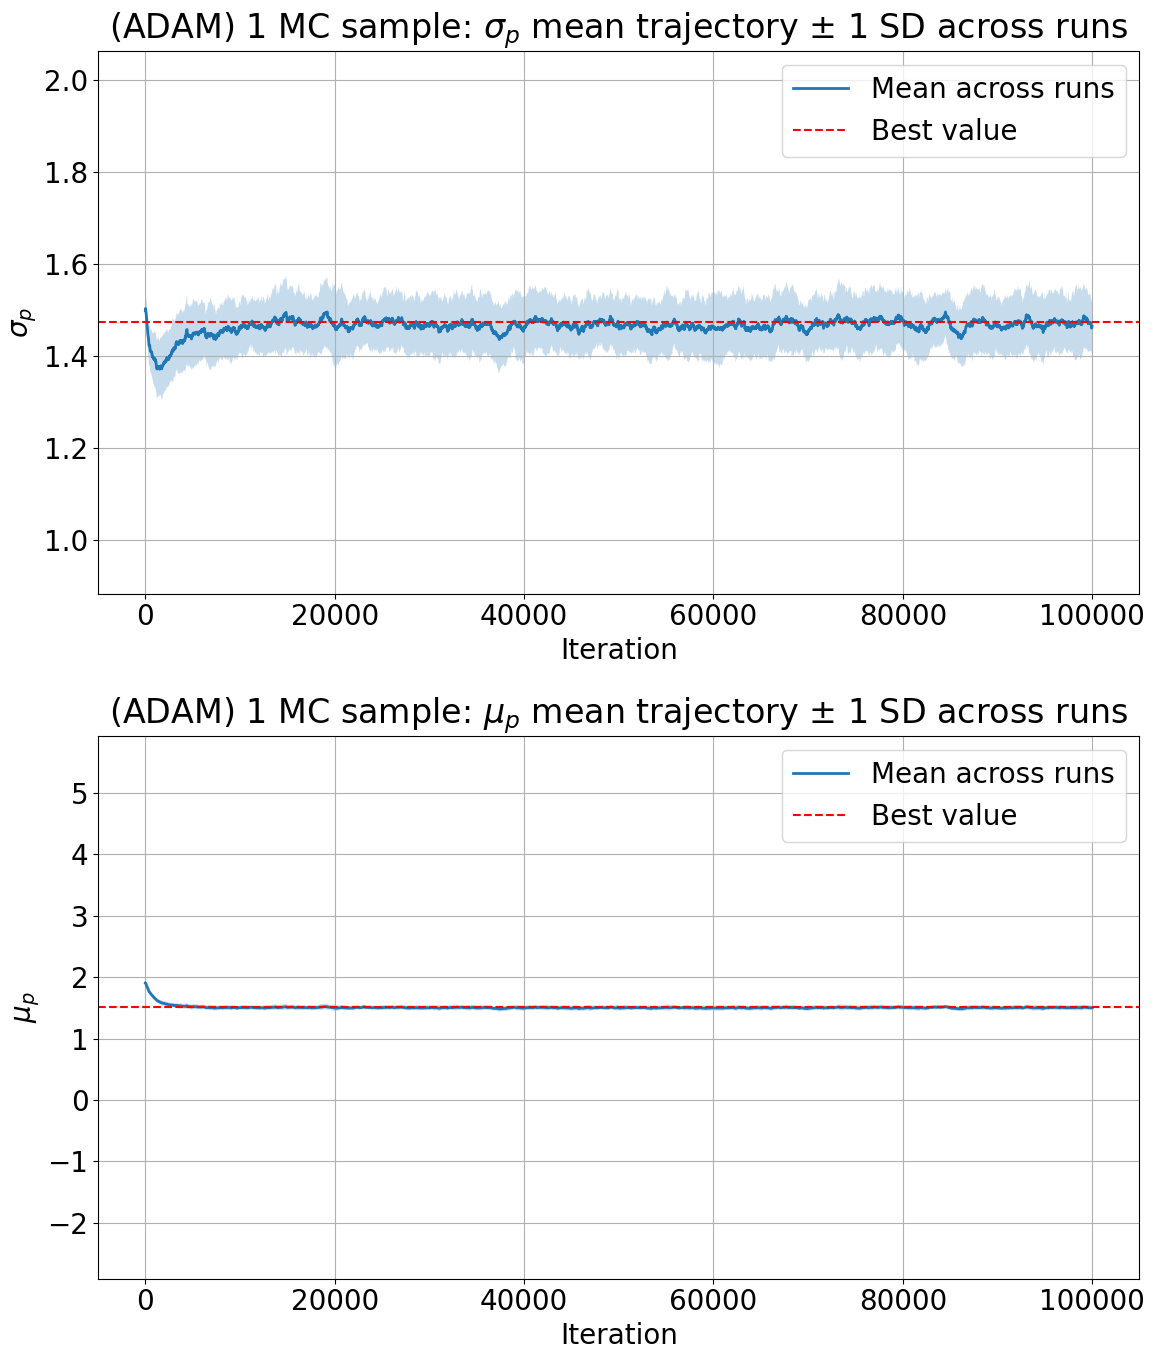

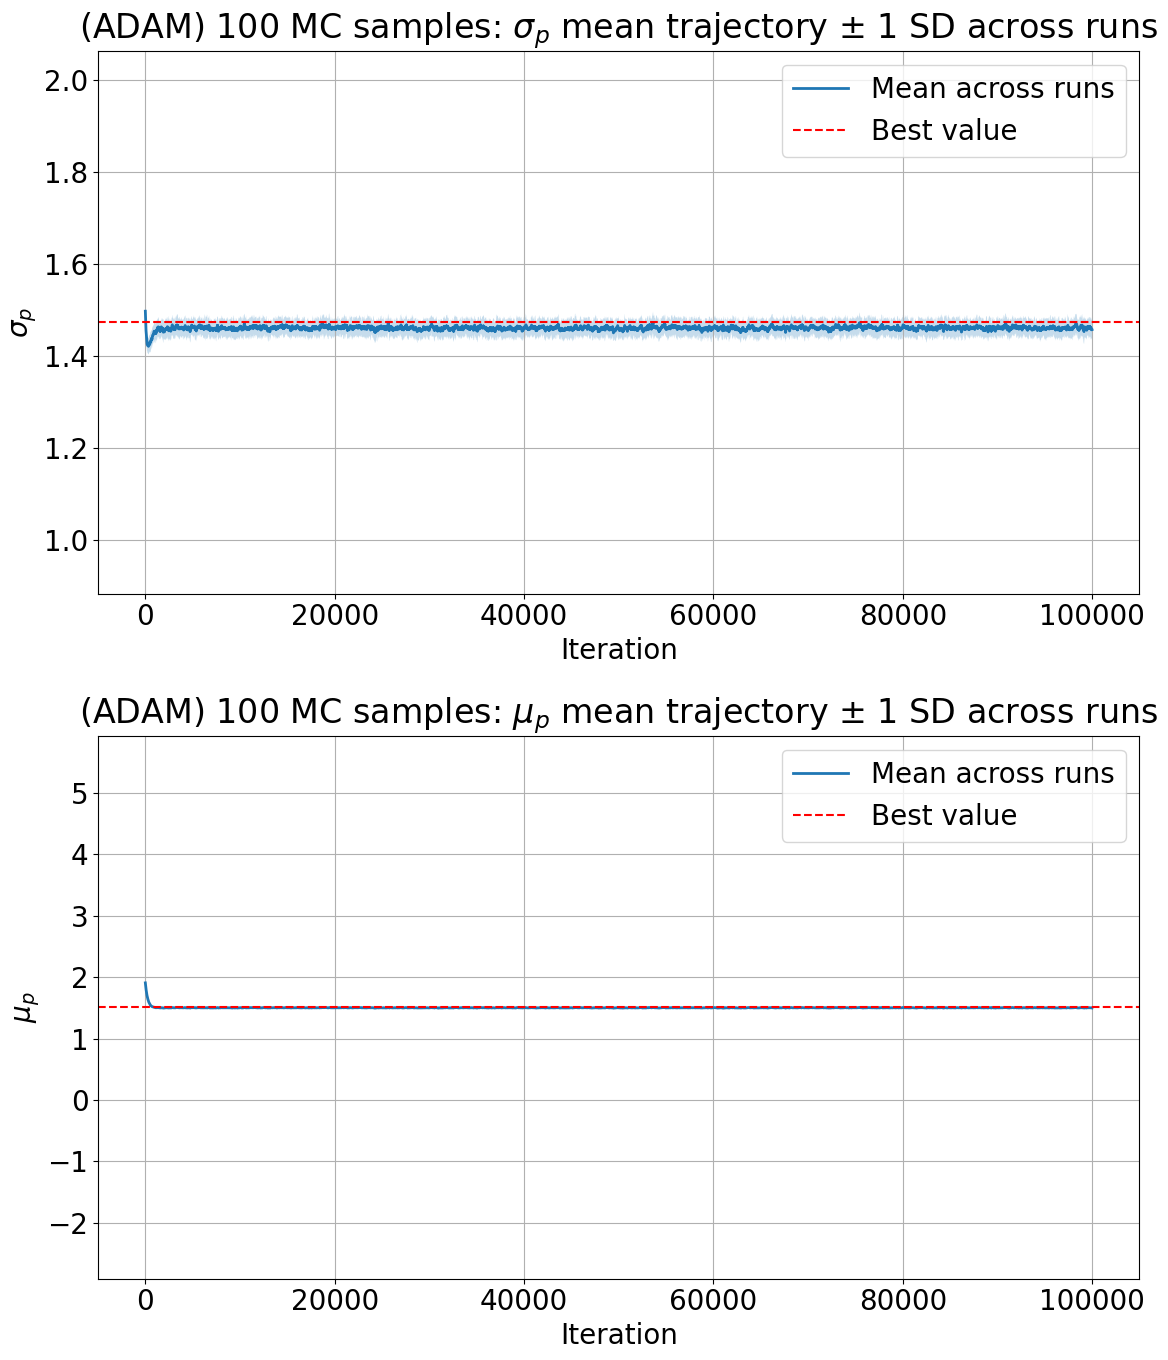

In [ ]:
plot_a_few_trajectories_1d(
    [single_means_adam, single_stds_adam], [multi_means_adam, multi_stds_adam],
    best_mu, best_std, r'$\lambda$', label_prefix = 'ADAM ')
plot_mean_band_rrs_1d(
    single_means_adam, single_stds_adam, best_mu, best_std,
    x, r'$\lambda$', 1, label_prefix='ADAM ')
plot_mean_band_rrs_1d(
    multi_means_adam, multi_stds_adam, best_mu, best_std,
    x, r'$\lambda$', 100, label_prefix='ADAM ')